# Task 2 – Image Classification: CNN vs Transfer Learning (LeNet-5 Fine-Tuning)

## Overview
This notebook implements and compares two image classification models on the same dataset:
- **Model 1:** A custom Convolutional Neural Network (CNN) built and trained from scratch.
- **Model 2:** A LeNet-5 architecture used in a transfer learning fashion — first pre-trained, saved, then fine-tuned with frozen base layers and a low learning rate.

Both models address class imbalance and are evaluated using accuracy, precision, recall, F1-score, balanced accuracy, and confusion matrices.


## 1. Dataset Paths
Define the file paths for the training and testing image/label binary files. These follow the IDX binary format used by the dataset.


In [1]:
train_images_path = '/content/train-images.idx3-ubyte'
train_labels_path = '/content/train-labels.idx1-ubyte'
test_images_path = '/content/t10k-images.idx3-ubyte'
test_labels_path = '/content/t10k-labels.idx1-ubyte'


## 2. Library Imports
All necessary libraries are imported here:
- `numpy`, `pandas` — data manipulation and analysis
- `matplotlib`, `seaborn` — visualisation of training curves, confusion matrices, and sample images
- `tensorflow` / `keras` — model building, training, and evaluation
- `sklearn` — evaluation metrics (classification report, confusion matrix, balanced accuracy) and class weight computation


In [2]:
import numpy as np
import pandas as pd
import struct
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam


## 3. Custom Data Loader Functions
The dataset is stored in IDX binary format (not a standard image folder). These two functions parse the binary file headers and extract raw pixel arrays and integer labels into numpy arrays compatible with Keras.


In [3]:
def load_mnist_images(file_path):
    with open(file_path, 'rb') as f:
        # Read the header: magic number, number of images, rows, cols [cite: 11, 27]
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)
        return images

def load_mnist_labels(file_path):
    with open(file_path, 'rb') as f:
        # Read the header: magic number, number of items [cite: 11, 27]
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
        return labels



## 4. Load Raw Data
Load training and test images/labels using the custom loader functions defined above. The number of samples is printed to confirm successful loading.


In [4]:
# Using the paths we defined
x_train_raw = load_mnist_images(train_images_path)
y_train_raw = load_mnist_labels(train_labels_path)
x_test_raw = load_mnist_images(test_images_path)
y_test_raw = load_mnist_labels(test_labels_path)

print(f"Data Loaded: {x_train_raw.shape[0]} training samples found.")
print(f"Data Loaded: {x_test_raw.shape[0]} testing samples found.")

print(f"Extraction Successful: {x_train_raw.shape[0]} training samples extracted.")

Data Loaded: 60000 training samples found.
Data Loaded: 10000 testing samples found.
Extraction Successful: 60000 training samples extracted.


## 5. Preprocessing

### 5.1 Normalisation & Reshaping
- **Normalisation:** Pixel values are scaled from [0–255] to [0.0–1.0]. This ensures faster gradient convergence and prevents large activations from dominating.
- **Reshaping:** CNNs require 4D input tensors of shape `(samples, height, width, channels)`. Since images are grayscale, channels = 1.
- **One-hot encoding:** Integer class labels are converted to categorical vectors (e.g., class 3 → [0,0,0,1,0,...]) as required by `categorical_crossentropy` loss.


In [5]:
# 1. Normalization: Scale pixels from 0-255 to 0-1 [cite: 98]
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

# 2. Reshaping: CNNs need 4D input (Samples, Height, Width, Channels) [cite: 31, 38]
# MNIST is grayscale, so Channels = 1
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train_raw, 10)
y_test_cat = to_categorical(y_test_raw, 10)

print("Labels one-hot encoded:", y_train_cat.shape)



Labels one-hot encoded: (60000, 10)


### 5.2 Data Quality Checks
Verifying there are no NaN values in the training or test arrays. NaN values would silently corrupt training without throwing an obvious error.


In [6]:
np.isnan(x_train).any()

np.False_

In [7]:
np.isnan(x_test).any()

np.False_

### 5.3 Shape Verification
Confirming the final tensor shapes are as expected before passing to models.


In [8]:
x_train.shape

(60000, 28, 28, 1)

In [9]:
x_test.shape

(10000, 28, 28, 1)

### 5.4 Visual Verification
Display the first 10 training images alongside their labels to confirm the data was loaded, reshaped, and labelled correctly.


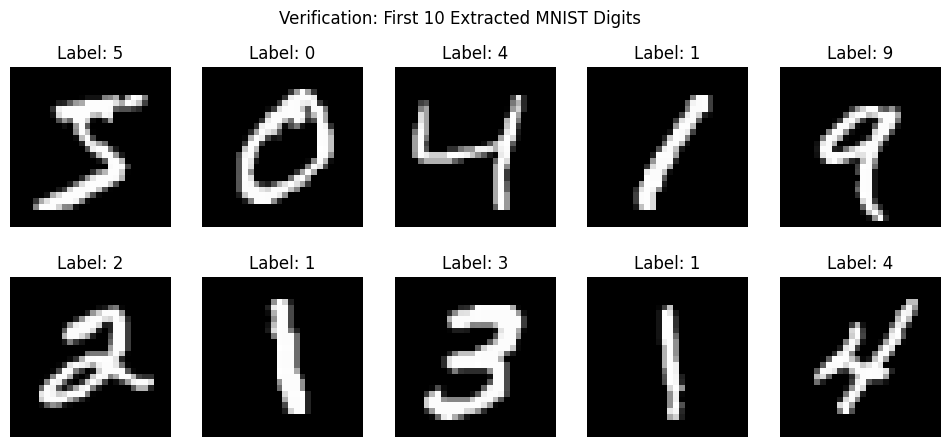

In [10]:
# Displaying the first 10 images in a grid to verify data integrity
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"Label: {y_train_raw[i]}")
    plt.axis('off')
plt.suptitle("Verification: First 10 Extracted MNIST Digits")
plt.show()


5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


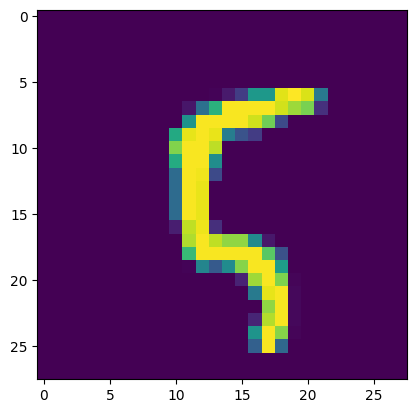

In [11]:
plt.imshow(x_train[100][:,:,0])
print(y_train_raw[100])
print(y_train_cat[100])


## 6. Class Distribution Analysis
Before training, we inspect how samples are distributed across classes. Significant imbalance (some classes having far more samples than others) would bias the model toward majority classes. This analysis guides our imbalance handling strategy.


In [12]:
import numpy as np
from collections import Counter

# If using numpy arrays (y_train)
labels = np.argmax(y_train_cat, axis=1)  # convert one-hot to labels

class_counts = Counter(labels)

print("Class distribution:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count}")


Class distribution:
Class 5: 5421
Class 0: 5923
Class 4: 5842
Class 1: 6742
Class 9: 5949
Class 2: 5958
Class 3: 6131
Class 6: 5918
Class 7: 6265
Class 8: 5851


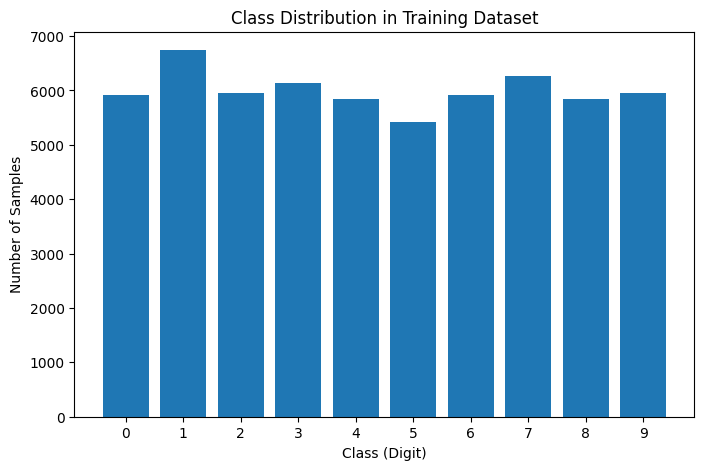

In [13]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.xlabel("Class (Digit)")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Dataset")
plt.xticks(classes)
plt.show()


## 7. Handling Class Imbalance

### 7.1 Class Weight Computation
`sklearn`'s `compute_class_weight('balanced', ...)` computes per-class weights inversely proportional to class frequency. These weights are passed to `model.fit()` via the `class_weight` argument, penalising misclassification of minority classes more heavily during training.


In [14]:

# 2. Compute class weights
# -----------------------
labels = y_train_raw  # integer labels
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights_array))
#class_weights = dict(zip(np.unique(labels), class_weights_array))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0130001688333614), 1: np.float64(0.8899436369029962), 2: np.float64(1.0070493454179255), 3: np.float64(0.978633175664655), 4: np.float64(1.0270455323519343), 5: np.float64(1.1068068622025458), 6: np.float64(1.013856032443393), 7: np.float64(0.9577015163607342), 8: np.float64(1.025465732353444), 9: np.float64(1.0085728693898135)}


### 7.2 Train / Validation Split
The first 6,000 samples are reserved as a validation set; the remainder forms the training set. The validation set is used to monitor generalisation and trigger early stopping — it is never seen during weight updates.


In [15]:

# Train / Validation Split

x_val = x_train[:6000]
y_val = y_train_cat[:6000]

x_train_new = x_train[6000:]
y_train_new = y_train_cat[6000:]


### 7.3 Data Augmentation
`ImageDataGenerator` applies random on-the-fly transformations to training images to artificially expand the dataset and improve generalisation:
- **Rotation ±10°:** Simulates slight orientation variation.
- **Width/Height shift 10%:** Simulates translation variation.
- **Zoom 10%:** Simulates scale variation.

No augmentation is applied to the validation set so that evaluation remains unbiased and consistent.


In [16]:

# Data Generators

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(x_train_new, y_train_new, batch_size=64)
val_generator = val_datagen.flow(x_val, y_val, batch_size=64)


---
## Model 1: Custom Convolutional Neural Network (CNN)

### 8. CNN Architecture
The model follows a classic deep CNN structure:
- **Conv2D(32) + MaxPooling:** Extracts low-level features (edges, textures) and reduces spatial dimensions.
- **Conv2D(64) + MaxPooling:** Extracts higher-level features using more filters.
- **Flatten:** Converts 2D feature maps into a 1D vector for the classifier.
- **Dense(128, relu):** Fully connected layer that combines features for classification.
- **Dropout(0.5):** Regularisation — randomly disables 50% of neurons during training to prevent overfitting.
- **Dense(10, softmax):** Output layer producing a probability distribution over 10 classes.

Compiled with **Adam** optimiser and **categorical crossentropy** loss — standard choices for multi-class classification.


In [17]:

# 4. CNN Model

def create_cnn_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_cnn_model()
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 9. Early Stopping Callback
Monitors `val_loss` and stops training if no improvement greater than 0.0005 is seen for 5 consecutive epochs. `restore_best_weights=True` ensures the model reverts to its best checkpoint, preventing overfitting from over-training.


In [18]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',        # more stable than accuracy
    patience=5,                # give model more chance to improve
    min_delta=0.0005,          # ignore very small changes
    restore_best_weights=True,
    verbose=1
)



### 10. Train the CNN
Train for up to 25 epochs using the augmented data generator, class weights, and early stopping. Training time is recorded for later comparison with the LeNet-5 model.


In [19]:

# 6. Train CNN

import time
start = time.time()

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights,
    callbacks=[ early_stop]
)

end = time.time()
print(f"Training time: {end - start:.2f} seconds ({(end - start)/60:.2f} minutes)")


Epoch 1/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 69s 79ms/step - accuracy: 0.8449 - loss: 0.4886 - val_accuracy: 0.9748 - val_loss: 0.0771
Epoch 2/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.9405 - loss: 0.1987 - val_accuracy: 0.9837 - val_loss: 0.0458
Epoch 3/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.9561 - loss: 0.1481 - val_accuracy: 0.9880 - val_loss: 0.0371
Epoch 4/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - accuracy: 0.9623 - loss: 0.1252 - val_accuracy: 0.9890 - val_loss: 0.0328
Epoch 5/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.9676 - loss: 0.1089 - val_accuracy: 0.9895 - val_loss: 0.0332
Epoch 6/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.9721 - loss: 0.0954 - val_accuracy: 0.9900 - val_loss: 0.0317
Epoch 7/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.9743 - loss: 0.0881 - val_accuracy: 0.9920 - val_loss: 0.0273
Epoch 8/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.9761 - loss: 0.0810 - 

### 11. CNN Training History
Accuracy and loss curves for both training and validation sets are plotted.

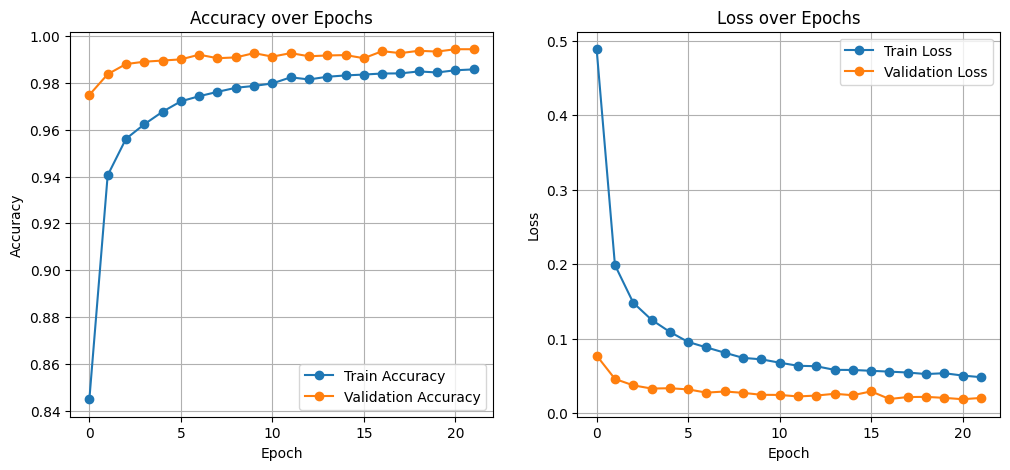

In [20]:
# Plot Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('CNN Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('CNN Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


### 12. CNN — Test Set Evaluation
The trained CNN is evaluated on the held-out test set. These metrics are unbiased since the test set was never used during training or validation.


In [21]:
#  Evaluate on Test Set
test_loss, test_acc = cnn_model.evaluate(x_test, y_test_cat)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")



313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9948 - loss: 0.0164
Test Loss: 0.0164, Test Accuracy: 0.9948


In [22]:
y_pred = cnn_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


### 13. CNN — Classification Report & Confusion Matrix
- **Classification report:** Per-class precision, recall, F1-score, and support — gives a detailed breakdown of where the model succeeds or struggles.
- **Confusion matrix heatmap:** Shows which classes are confused with each other. High off-diagonal values indicate systematic errors between similar-looking classes.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      1.00      1.00      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



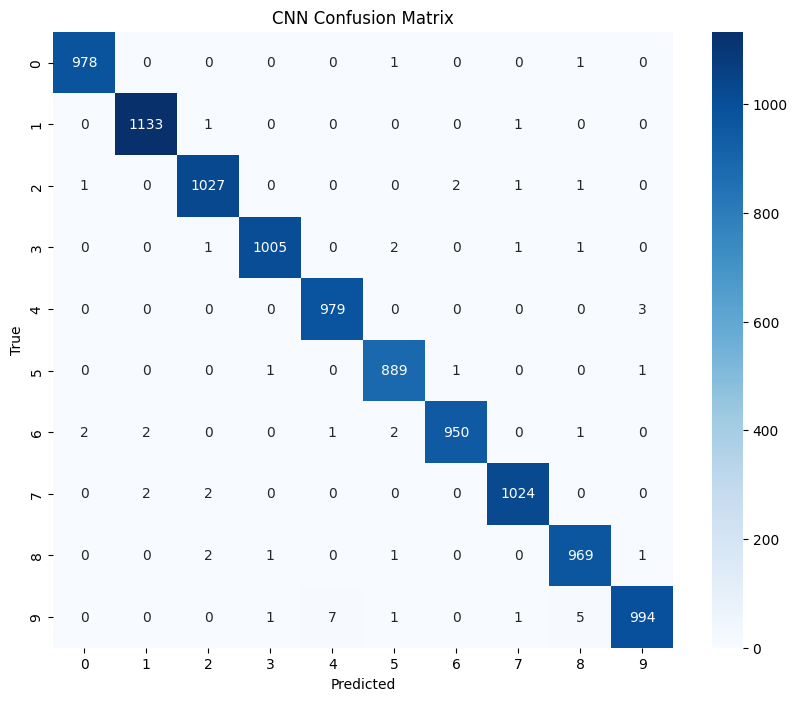

In [23]:
#  Confusion Matrix & Classification Report
print(classification_report(y_test_raw, y_pred_classes))

cm = confusion_matrix(y_test_raw, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.show()


### 14. CNN — Misclassified Sample Visualisation
Visualising misclassified images helps identify failure patterns (e.g., ambiguous samples, visually similar classes). This qualitative analysis complements the quantitative metrics above.


Total misclassified samples: 52


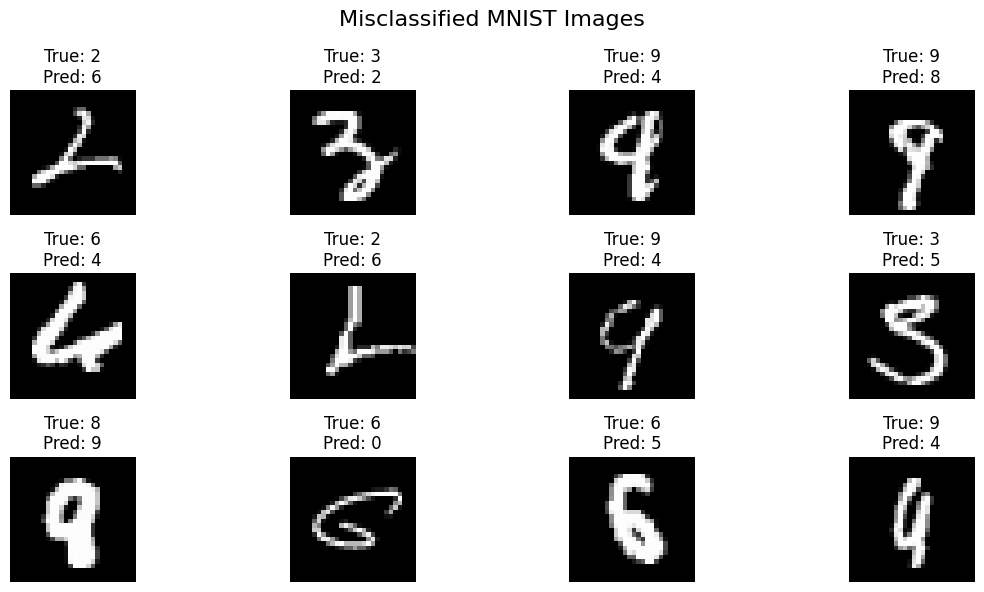

In [24]:
# Find misclassified indices
misclassified_idx = np.where(y_test_raw != y_pred_classes)[0]
print(f"Total misclassified samples: {len(misclassified_idx)}")

# Plot some misclassified images
num_to_plot = min(12, len(misclassified_idx))  # plot up to 12 misclassified
plt.figure(figsize=(12,6))

for i in range(num_to_plot):
    idx = misclassified_idx[i]
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[idx][:,:,0], cmap='gray')
    plt.title(f"True: {y_test_raw[idx]}\nPred: {y_pred_classes[idx]}")
    plt.axis('off')

plt.suptitle("Misclassified MNIST Images", fontsize=16)
plt.tight_layout()
plt.show()

---
## Model 2: LeNet-5 via Transfer Learning

### 15. LeNet-5 Architecture
LeNet-5 is a foundational CNN architecture used here in a **transfer learning workflow**:
1. **Pre-training phase:** Trained from scratch on the full dataset to learn general feature representations.
2. **Fine-tuning phase:** Reloaded, base layers frozen, and only the classifier head re-trained with a low learning rate.

This simulates the standard transfer learning paradigm (pre-trained base → fine-tune head), applied here using LeNet-5 as the base model as directed.

Architecture:
- Conv2D(6, 5×5) + AveragePooling — first feature extraction block
- Conv2D(16, 5×5) + AveragePooling — second feature extraction block
- Dense(120) → Dense(84) → Dense(10, softmax) — classifier head


In [25]:

def create_lenet_model():
    model = Sequential([
        Conv2D(6, (5,5), activation='relu', input_shape=(28,28,1)),
        AveragePooling2D((2,2)),

        Conv2D(16, (5,5), activation='relu'),
        AveragePooling2D((2,2)),

        Flatten(),
        Dense(120, activation='relu'),
        Dense(84, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [26]:
lenet_model = create_lenet_model()
lenet_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

### 16. Pre-training Phase — Initial LeNet-5 Training
LeNet-5 is trained from scratch. This is the **pre-training phase** of the transfer learning workflow — the model learns feature representations from the dataset that will later be adapted through fine-tuning.


In [27]:
import time
start = time.time()

history_lenet = lenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop]
)

end = time.time()
print(f"Initial Training Time: {end - start:.2f} seconds")

Epoch 1/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.8336 - loss: 0.5311 - val_accuracy: 0.9625 - val_loss: 0.1355
Epoch 2/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - accuracy: 0.9429 - loss: 0.1898 - val_accuracy: 0.9760 - val_loss: 0.0845
Epoch 3/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.9555 - loss: 0.1465 - val_accuracy: 0.9777 - val_loss: 0.0807
Epoch 4/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.9633 - loss: 0.1215 - val_accuracy: 0.9800 - val_loss: 0.0677
Epoch 5/25
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9664 - loss: 0.1082 - val_accuracy: 0.9788 - val_loss: 0.0690
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Initial Training Time: 269.42 seconds


### 17. Save the Pre-trained Model
The trained model is saved to disk as `lenet_pretrained.keras`. This checkpoint acts as our "pre-trained base" — equivalent to saving downloaded weights from a pre-trained model before fine-tuning begins.


In [28]:
lenet_model.save("lenet_pretrained.keras")

### 18. LeNet-5 Pre-training History
Training and validation accuracy/loss curves for the initial pre-training phase.


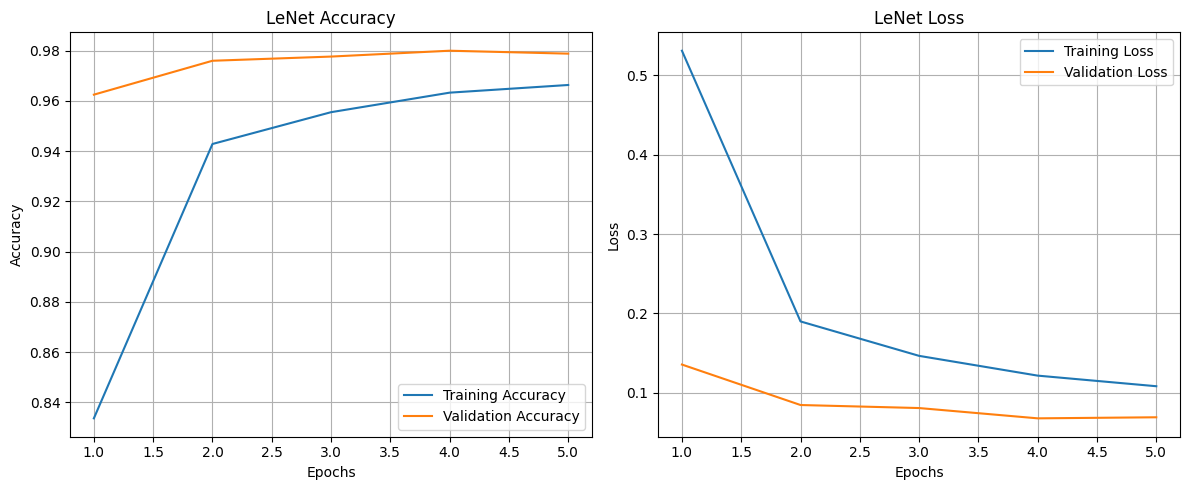

In [29]:
history = history_lenet.history
epochs = range(1, len(history['accuracy']) + 1)
plt.figure(figsize=(12, 5))

# -------- Accuracy Plot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
plt.title('LeNet Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss Plot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, history['loss'], label='Training Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.title('LeNet Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 19. Reload Pre-trained LeNet-5
The saved model is reloaded fresh from disk. This cleanly separates the pre-training and fine-tuning phases, mirroring the real-world workflow of loading a pre-trained model.


In [30]:
from tensorflow.keras.models import load_model

lenet_model = load_model("lenet_pretrained.keras")

### 20. Freeze Base Layers — Transfer Learning Setup
All layers are frozen first (weights not updated during backpropagation). The last 3 layers (classifier head) are then selectively unfrozen for fine-tuning.

**Rationale:** The convolutional base has already learned useful spatial features. Freezing it preserves this knowledge and prevents catastrophic forgetting. Only the classification layers are updated to adapt the model to the target task.


In [31]:
# Freeze all layers
for layer in lenet_model.layers:
    layer.trainable = False

# Unfreeze last 2–3 layers
for layer in lenet_model.layers[-3:]:
    layer.trainable = True

### 21. Recompile with Low Learning Rate
The model is recompiled with a small learning rate (`1e-4`). A high learning rate during fine-tuning would overwrite the pre-trained weights with large random updates — a small rate makes careful, incremental adjustments.


In [32]:
from tensorflow.keras.optimizers import Adam

lenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 22. Fine-Tuning Phase
Fine-tune the partially frozen LeNet-5. With the convolutional base locked, training focuses on adapting the classifier head. Class weights and early stopping are applied consistently with the CNN training setup.


In [33]:
start = time.time()

history_finetune = lenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop]

)

end = time.time()
print(f"Fine-Tuning Time: {end - start:.2f} seconds")

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.9462 - loss: 0.1830 - val_accuracy: 0.9727 - val_loss: 0.0955
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9501 - loss: 0.1681 - val_accuracy: 0.9747 - val_loss: 0.0889
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9524 - loss: 0.1633 - val_accuracy: 0.9762 - val_loss: 0.0855
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 0.9542 - loss: 0.1538 - val_accuracy: 0.9773 - val_loss: 0.0839
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.9568 - loss: 0.1458 - val_accuracy: 0.9778 - val_loss: 0.0804
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Fine-Tuning Time: 164.14 seconds


### 23. Fine-Tuning Training History
Accuracy and loss curves for the fine-tuning phase. Compared to the pre-training curves, we expect faster convergence and more stable validation performance.


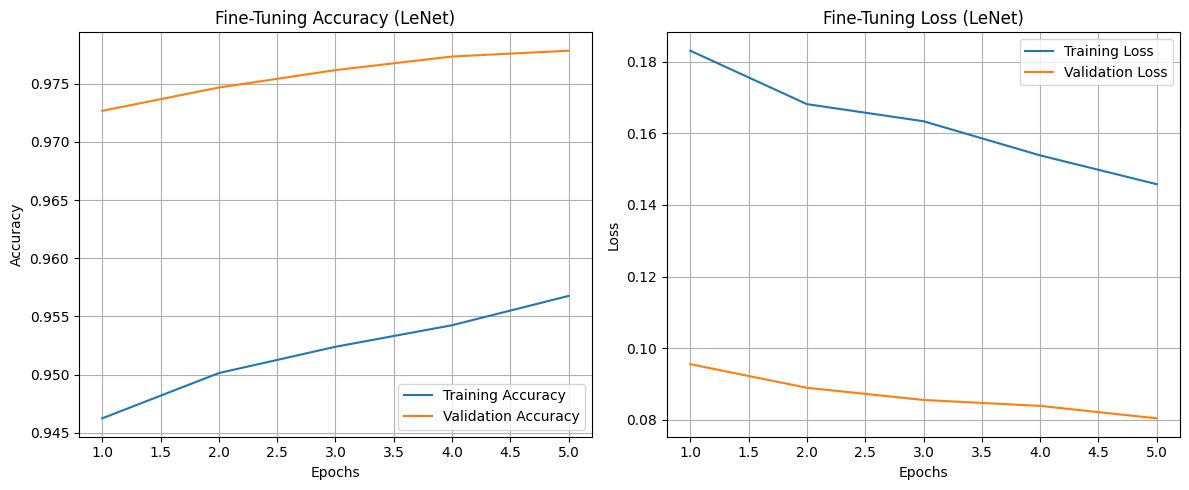

In [34]:
import matplotlib.pyplot as plt
history = history_finetune.history
epochs = range(1, len(history['accuracy']) + 1)
plt.figure(figsize=(12, 5))

# -------- Accuracy --------
plt.subplot(1, 2, 1)
plt.plot(epochs, history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
plt.title('Fine-Tuning Accuracy (LeNet)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss --------
plt.subplot(1, 2, 2)
plt.plot(epochs, history['loss'], label='Training Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.title('Fine-Tuning Loss (LeNet)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 24. LeNet-5 (Fine-Tuned) — Test Evaluation
Evaluate the fine-tuned LeNet-5 on the held-out test set.


In [35]:
# Evaluate LeNet (fine-tuned model)
test_loss, test_acc = lenet_model.evaluate(x_test, y_test_cat)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9734 - loss: 0.0872
Test Loss: 0.0872
Test Accuracy: 0.9734


In [36]:
# Predictions
y_pred_probs = lenet_model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = y_test_raw

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


### 25. LeNet-5 — Classification Report
Per-class precision, recall, and F1-score for the fine-tuned LeNet-5. These results are directly comparable to the CNN classification report above.


In [37]:
from sklearn.metrics import classification_report

print("LeNet Classification Report:")
print(classification_report(y_true, y_pred_classes))

LeNet Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.97      0.95      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



### 26. LeNet-5 — Confusion Matrix
Confusion matrix heatmap for the fine-tuned LeNet-5, showing prediction errors across all classes.


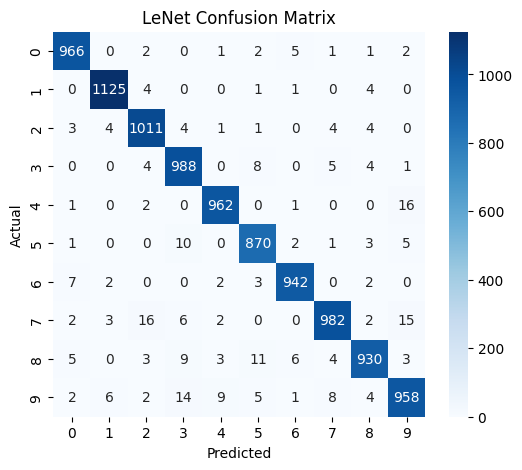

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("LeNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 27. LeNet-5 — Misclassified Sample Visualisation
Visual inspection of misclassified images from the fine-tuned LeNet-5 for qualitative error analysis alongside the classification report.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Total misclassified samples (LeNet): 266


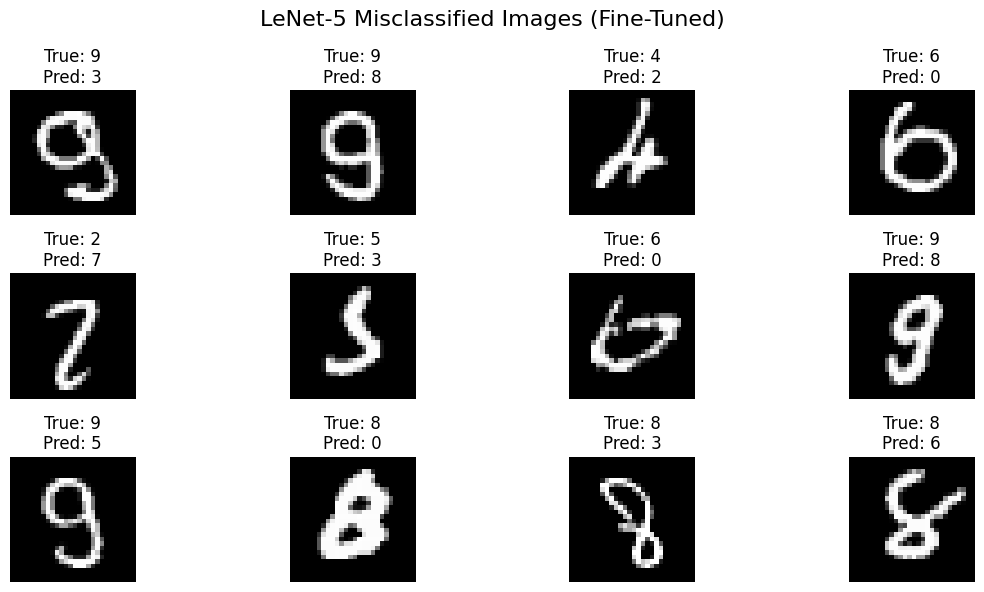

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Predict using fine-tuned LeNet model
y_pred_probs = lenet_model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = y_test_raw

# Find misclassified indices
misclassified_idx = np.where(y_true != y_pred_classes)[0]
print(f"Total misclassified samples (LeNet): {len(misclassified_idx)}")

# Plot some misclassified images
num_to_plot = min(12, len(misclassified_idx))
plt.figure(figsize=(12,6))

for i in range(num_to_plot):
    idx = misclassified_idx[i]
    plt.subplot(3, 4, i+1)

    plt.imshow(x_test[idx].squeeze(), cmap='gray')  # safer than [:,:,0]

    plt.title(f"True: {y_true[idx]}\nPred: {y_pred_classes[idx]}")
    plt.axis('off')

plt.suptitle("LeNet-5 Misclassified Images (Fine-Tuned)", fontsize=16)
plt.tight_layout()
plt.show()

---
## 30. Final Model Comparison: CNN vs LeNet-5 (Transfer Learning)

Both models are evaluated on the same held-out test set. Results are summarised in a table and visualised as a bar chart.

This comparison addresses the core assignment objective: determining which architecture performs better, and understanding the trade-offs between a custom CNN and a transfer learning approach in terms of accuracy and complexity.



--- Model Performance Comparison ---
           Model Test Loss Test Accuracy
      Custom CNN    0.0164        0.9948
LeNet (Transfer)    0.0872        0.9734
----------------------------------------


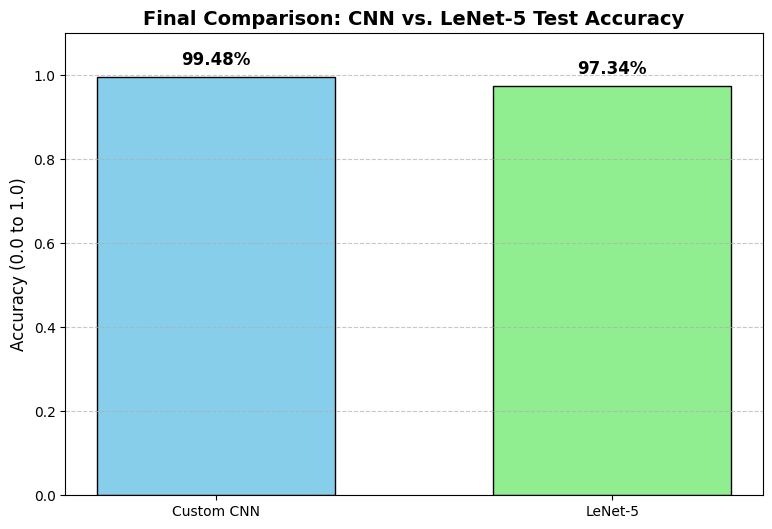

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Evaluate CNN Model
cnn_loss, cnn_acc = cnn_model.evaluate(x_test, y_test_cat, verbose=0)

# 2. Evaluate LeNet Model
# (Assuming your transfer learning model is named lenet_model)
lenet_loss, lenet_acc = lenet_model.evaluate(x_test, y_test_cat, verbose=0)

# --- 3. DISPLAY COMPARISON TABLE ---
data = {
    "Model": ["Custom CNN", "LeNet (Transfer)"],
    "Test Loss": [f"{cnn_loss:.4f}", f"{lenet_loss:.4f}"],
    "Test Accuracy": [f"{cnn_acc:.4f}", f"{lenet_acc:.4f}"]
}

df = pd.DataFrame(data)
print("\n--- Model Performance Comparison ---")
print(df.to_string(index=False))
print("-" * 40)

# --- 4. VISUALIZATION ---
models = ['Custom CNN', 'LeNet-5']
accuracies = [cnn_acc, lenet_acc]

plt.figure(figsize=(9, 6))
colors = ['skyblue', 'lightgreen']
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.6)

# Formatting the chart
plt.ylabel('Accuracy (0.0 to 1.0)', fontsize=12)
plt.title('Final Comparison: CNN vs. LeNet-5 Test Accuracy', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)  # Leave space at the top for labels
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

In [42]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Get Predictions for BOTH models ---
cnn_pred = cnn_model.predict(x_test)
cnn_pred_classes = np.argmax(cnn_pred, axis=1)

lenet_pred = lenet_model.predict(x_test)
lenet_pred_classes = np.argmax(lenet_pred, axis=1)

# --- 2. Classification Reports as dict ---
cnn_report = classification_report(y_test_raw, cnn_pred_classes, output_dict=True)
lenet_report = classification_report(y_test_raw, lenet_pred_classes, output_dict=True)

# --- 3. Extract weighted avg (best for imbalance) ---
data = {
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Custom CNN": [
        cnn_report['weighted avg']['precision'],
        cnn_report['weighted avg']['recall'],
        cnn_report['weighted avg']['f1-score']
    ],
    "LeNet (Transfer)": [
        lenet_report['weighted avg']['precision'],
        lenet_report['weighted avg']['recall'],
        lenet_report['weighted avg']['f1-score']
    ]
}

df_metrics = pd.DataFrame(data)

print("\n--- Classification Metrics Comparison ---")
print(df_metrics.to_string(index=False))
print("-" * 50)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

--- Classification Metrics Comparison ---
   Metric  Custom CNN  LeNet (Transfer)
Precision    0.994805          0.973434
   Recall    0.994800          0.973400
 F1-Score    0.994798          0.973374
--------------------------------------------------


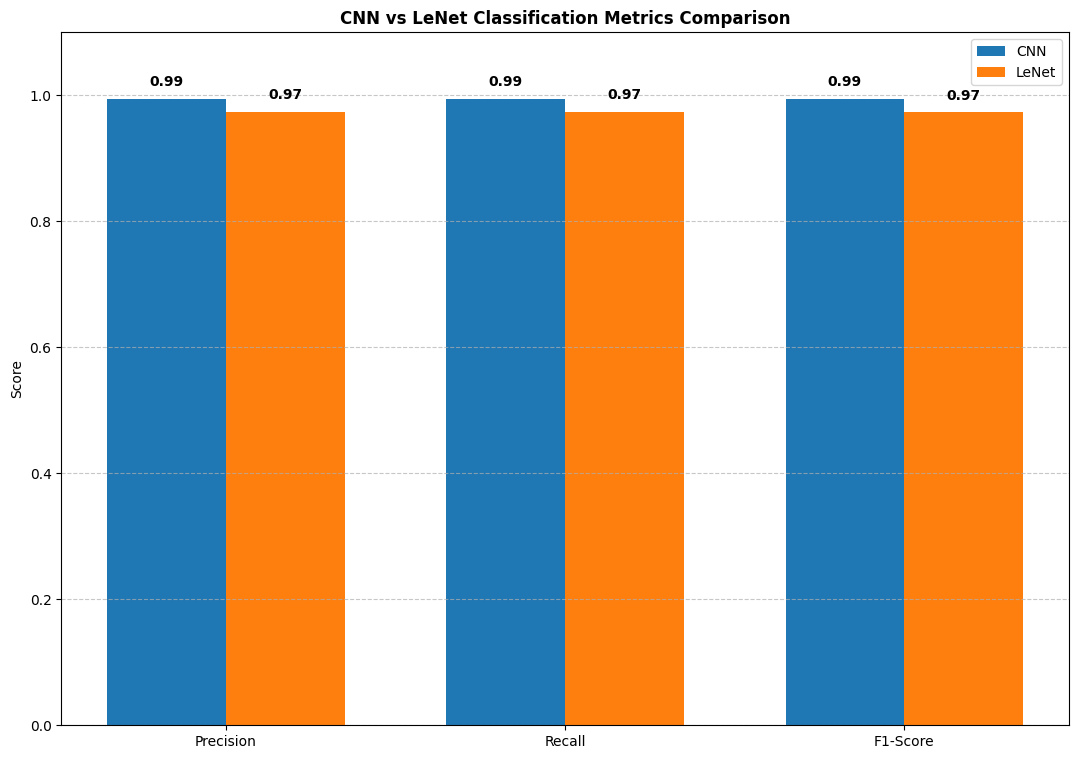

In [49]:

comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Custom CNN": [
        cnn_report['weighted avg']['precision'],
        cnn_report['weighted avg']['recall'],
        cnn_report['weighted avg']['f1-score']
    ],
    "LeNet (Fine-Tuned)": [
        lenet_report['weighted avg']['precision'],
        lenet_report['weighted avg']['recall'],
        lenet_report['weighted avg']['f1-score']
    ]
})

x = np.arange(len(comparison["Metric"]))
width = 0.35

plt.figure(figsize=(13,9))

bars1 = plt.bar(x - width/2, comparison["Custom CNN"], width, label='CNN')
bars2 = plt.bar(x + width/2, comparison["LeNet (Fine-Tuned)"], width, label='LeNet')

plt.xticks(x, comparison["Metric"])
plt.ylabel("Score")
plt.title("CNN vs LeNet Classification Metrics Comparison", fontweight='bold')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.show()